# AOD DDS Lab Control Notebook — Plan B Concise (RIGOL Version)

**Purpose:** Control and test the Spectrum M4i.6622-x8 DDS on the lab computer while using the RIGOL only as a manually operated oscilloscope / FFT display.

This version does **not** require any computer connection to the RIGOL.

### Hardware path
`Lab computer → Spectrum M4i.6622-x8 CH0 → 50 Ω coax → RIGOL`

### Included tests
1. Card / DDS initialization
2. Single tone
3. Multi-tone
4. Discrete live frequency jumps
5. Timer-triggered frequency steps
6. Simple linear frequency ramp
7. Continuous linear-ramp animation
8. **Complex S-shaped frequency ramps based specifically on `src/examples/03_dds/12_dds_complex_ramps.py`**

For the current RIGOL FFT test, **Vrms** is preferred over dBV because it has given a clearer / more useful FFT display in practice.

**Do not connect the RF amplifier or AOD until the direct Spectrum → RIGOL test is understood.**


### Install `spcm`

Run this first in the Jupyter kernel used for the experiment.


## 1. Environment Check

This cell only imports the packages used for Spectrum DDS control and local plotting / animation.


In [1]:
import sys
import time
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display

import spcm
from spcm import units

print("Python:", sys.version.split()[0])
print("spcm imported successfully")


Python: 3.13.12
spcm imported successfully


## 2. Main Lab Configuration

These are the stable hardware settings for the current Spectrum card. Experiment-specific frequencies / amplitudes remain in the corresponding test sections.


In [2]:
DEVICE = "/dev/spcm0"
EXPECTED_MODEL = "M4i.6622-x8"
EXPECTED_SERIAL = 23161

CHANNEL = spcm.CHANNEL0
LOAD = 50 * units.ohm
CHANNEL_RANGE = 0.5 * units.V

print("Device:", DEVICE)
print("Expected model:", EXPECTED_MODEL)
print("Expected serial:", EXPECTED_SERIAL)


Device: /dev/spcm0
Expected model: M4i.6622-x8
Expected serial: 23161


### Reusable Spectrum Setup Helpers

Only repeated Spectrum initialization / start / stop code is placed here. The actual DDS commands for each experiment remain visible in the corresponding cells.


In [3]:
def open_dds(channel_range=CHANNEL_RANGE):
    card = spcm.Card(DEVICE).open()

    try:
        if card.product_name() != EXPECTED_MODEL or card.sn() != EXPECTED_SERIAL:
            raise RuntimeError(
                f"Unexpected card: {card.product_name()}, serial {card.sn()}"
            )

        card.card_mode(spcm.SPC_REP_STD_DDS)

        channels = spcm.Channels(
            card,
            card_enable=CHANNEL,
        )
        channels[0].enable(True)
        channels[0].output_load(LOAD)
        channels[0].amp(channel_range)

        card.write_setup()  # required for DDS clock signals

        dds = spcm.DDS(
            card,
            channels=channels,
        )
        dds.reset()

        return card, dds

    except Exception:
        card.close()
        raise


def start_output(card):
    card.start(
        spcm.M2CMD_CARD_ENABLETRIGGER,
        spcm.M2CMD_CARD_FORCETRIGGER,
    )


def stop_output(card):
    try:
        card.stop()
    finally:
        card.close()


## 3. Card Connection Check

Opens the card, reads its identity, verifies model and serial number, then closes it.

No RF output is started here.


In [4]:
with spcm.Card(DEVICE) as card:
    model = card.product_name()
    serial = card.sn()

    print("Connected successfully")
    print("Model:", model)
    print("Serial:", serial)

    if model != EXPECTED_MODEL or serial != EXPECTED_SERIAL:
        raise RuntimeError(
            f"Unexpected card: {model}, serial {serial}"
        )

print("Connection check passed")


Connected successfully
Model: M4i.6622-x8
Serial: 23161
Connection check passed


## 4. DDS Initialization Check

Verifies that the card can enter DDS mode and reports the available DDS cores.

No RF output is started here.


In [5]:
card, dds = open_dds()

print("DDS initialized successfully")
print("Available DDS cores:", len(dds))

stop_output(card)
print("DDS initialization check passed")


DDS initialized successfully
Available DDS cores: 23
DDS initialization check passed


## 5. Single-Tone Scope Test — Settings

Use this first:

`M4i CH0 → 50 Ω coax → RIGOL`

Before running:
- configure the RIGOL input appropriately for the 50 Ω RF measurement chain;
- verify the time-domain waveform;
- use the built-in RIGOL FFT;
- use **Vrms** for the FFT amplitude display for the present test.


In [6]:
TEST_FREQUENCY = 100 * units.MHz
TEST_AMPLITUDE = 100 * units.mV
TEST_PHASE = 0 * units.degrees

print("Frequency:", TEST_FREQUENCY)
print("DDS amplitude:", TEST_AMPLITUDE)
print("Phase:", TEST_PHASE)


Frequency: 100 MHz
DDS amplitude: 100 mV
Phase: 0 deg


## 6. Single-Tone RF Output

This cell starts one DDS carrier on CH0 and leaves it running so it can be inspected on the RIGOL.


In [7]:
card, dds = open_dds()

dds[0].freq(TEST_FREQUENCY)
dds[0].amp(TEST_AMPLITUDE)
dds[0].phase(TEST_PHASE)

print("Programmed frequency:", dds[0].get_freq(return_unit=units.MHz))
print("Programmed amplitude:", dds[0].get_amp(return_unit=units.mV))
print("Programmed phase:", dds[0].get_phase(return_unit=units.degrees))

dds.exec_at_trg()
dds.write_to_card()
start_output(card)

print("RF output ON")
print("Check the waveform and FFT directly on the RIGOL.")


Programmed frequency: 100.00000009313226 MHz
Programmed amplitude: 99.9938962981048 mV
Programmed phase: 0.0 deg
RF output ON
Check the waveform and FFT directly on the RIGOL.


### Stop Single-Tone Output

Run this after the RIGOL measurement is complete.


In [8]:
stop_output(card)
print("RF output OFF")


RF output OFF


## 7. Manual RIGOL Verification

No oscilloscope waveform is transferred back to Python in this version.

For a single tone, verify directly on the RIGOL:
- correct time-domain frequency;
- reasonable amplitude;
- one dominant FFT peak at the programmed RF frequency;
- FFT amplitude display in **Vrms**.

For a 100 MHz tone, if the FFT peak is missing, first check:
- RIGOL sample rate is high enough;
- FFT center / span includes 100 MHz;
- FFT source is the correct channel;
- time base is not so long that the sample rate collapses;
- vertical scale uses a useful fraction of the ADC range.


## 8. Multi-Tone Scope Test — Settings

Only use this after the single-tone test works.

Each programmed frequency uses one DDS core.


In [9]:
MULTI_FREQUENCIES = [
    100 * units.MHz,
    110 * units.MHz,
]

MULTI_TOTAL_AMPLITUDE = 10 * units.percent
MULTI_PHASE = 0 * units.degrees

print("Number of tones:", len(MULTI_FREQUENCIES))
print("Frequencies:", MULTI_FREQUENCIES)
print("Total DDS amplitude budget:", MULTI_TOTAL_AMPLITUDE)


Number of tones: 2
Frequencies: [<Quantity(100, 'megahertz')>, <Quantity(110, 'megahertz')>]
Total DDS amplitude budget: 10 %


## 9. Multi-Tone RF Output

Use the RIGOL FFT to verify that all programmed tones are present.


In [10]:
card, dds = open_dds()

if len(MULTI_FREQUENCIES) > len(dds):
    raise ValueError(
        f"Requested {len(MULTI_FREQUENCIES)} tones, "
        f"but only {len(dds)} DDS cores are available."
    )

amp_each = MULTI_TOTAL_AMPLITUDE / len(MULTI_FREQUENCIES)

for i, frequency in enumerate(MULTI_FREQUENCIES):
    dds[i].freq(frequency)
    dds[i].amp(amp_each)
    dds[i].phase(MULTI_PHASE)

    print(
        f"Core {i}: "
        f"{dds[i].get_freq(return_unit=units.MHz)}, "
        f"{dds[i].get_amp(return_unit=units.percent)}"
    )

dds.exec_at_trg()
dds.write_to_card()
start_output(card)

print("Multi-tone RF output ON")
print("Check the peaks directly on the RIGOL FFT.")


Core 0: 100.00000009313226 MHz, 0.0499893185216834 %
Core 1: 109.99999998603016 MHz, 0.0499893185216834 %
Multi-tone RF output ON
Check the peaks directly on the RIGOL FFT.


### Stop Multi-Tone Output

Run this after the RIGOL FFT measurement is complete.


In [11]:
stop_output(card)
print("RF output OFF")


RF output OFF


## 10. Frequency Movement Tests

The notebook controls the Spectrum DDS. The RIGOL is only used as a manual observer.

Included:
1. live discrete jumps;
2. timer-triggered steps;
3. simple linear ramp;
4. linear-ramp animation;
5. complex S-shaped multi-carrier ramps from Spectrum's `12_dds_complex_ramps.py`.


### 10.1 Test A — Live Frequency Jump

The card remains running while core 0 moves through several discrete frequencies.

Each frequency is held long enough to observe manually on the RIGOL.


In [12]:
FREQ_MOVE_POINTS_MHZ = [95, 99, 103, 107, 111]
FREQ_MOVE_AMPLITUDE = 100 * units.mV
FREQ_MOVE_PHASE = 0 * units.degrees

FREQ_MOVE_HOLD_TIME_S = 3.0

print("Frequency setpoints [MHz]:", FREQ_MOVE_POINTS_MHZ)
print("Hold time per frequency:", FREQ_MOVE_HOLD_TIME_S, "s")


Frequency setpoints [MHz]: [95, 99, 103, 107, 111]
Hold time per frequency: 3.0 s


In [13]:
card, dds = open_dds()

dds.trg_src(spcm.SPCM_DDS_TRG_SRC_NONE)
dds[0].amp(FREQ_MOVE_AMPLITUDE)
dds[0].phase(FREQ_MOVE_PHASE)
dds[0].freq(FREQ_MOVE_POINTS_MHZ[0] * units.MHz)

dds.exec_at_trg()
dds.write_to_card()

try:
    start_output(card)
    print("RF OUTPUT ON")

    for i, f_MHz in enumerate(FREQ_MOVE_POINTS_MHZ):
        if i:
            dds[0].freq(f_MHz * units.MHz)
            dds.exec_now()
            dds.write_to_card()

        print(f"Current frequency: {f_MHz:.3f} MHz")
        time.sleep(FREQ_MOVE_HOLD_TIME_S)

finally:
    stop_output(card)
    print("RF OUTPUT OFF")


RF OUTPUT ON
Current frequency: 95.000 MHz
Current frequency: 99.000 MHz
Current frequency: 103.000 MHz
Current frequency: 107.000 MHz
Current frequency: 111.000 MHz
RF OUTPUT OFF


### 10.2 Test B — DDS Timer-Triggered Frequency Steps

Several frequencies are queued before the card starts. The internal DDS timer advances through them automatically.

Watch the discrete movement directly on the RIGOL FFT.


In [14]:
TIMED_FREQUENCIES_MHZ = [95, 103, 111]
TIMED_STEP_PERIOD_S = 3.0
TIMED_AMPLITUDE = 100 * units.mV

card, dds = open_dds()

dds.trg_src(spcm.SPCM_DDS_TRG_SRC_TIMER)
dds.trg_timer(TIMED_STEP_PERIOD_S * units.s)
dds[0].amp(TIMED_AMPLITUDE)

for f_MHz in TIMED_FREQUENCIES_MHZ:
    dds[0].freq(f_MHz * units.MHz)
    dds.exec_at_trg()

dds.write_to_card()

try:
    start_output(card)
    print("TIMED FREQUENCY MOVEMENT ON")
    time.sleep(
        TIMED_STEP_PERIOD_S
        * (len(TIMED_FREQUENCIES_MHZ) + 1)
    )
finally:
    stop_output(card)
    print("RF OUTPUT OFF")


TIMED FREQUENCY MOVEMENT ON
RF OUTPUT OFF


### 10.3 Test C — Simple Linear Frequency Ramp

This uses `frequency_slope()` to move one DDS carrier continuously from the start frequency to the stop frequency.

Watch the FFT peak move continuously on the RIGOL.


In [15]:
RAMP_START_MHZ = 95
RAMP_STOP_MHZ = 111
RAMP_TIME_S = 5.0
RAMP_FINAL_HOLD_S = 2.0

RAMP_AMPLITUDE = 100 * units.mV
RAMP_STEP_DIVIDER = 1000

slope = (
    (RAMP_STOP_MHZ - RAMP_START_MHZ)
    * units.MHz
    / (RAMP_TIME_S * units.s)
)

card, dds = open_dds()

dds.trg_src(spcm.SPCM_DDS_TRG_SRC_TIMER)
dds.trg_timer(RAMP_TIME_S * units.s)
dds.freq_ramp_stepsize(RAMP_STEP_DIVIDER)

dds[0].amp(RAMP_AMPLITUDE)
dds[0].freq(RAMP_START_MHZ * units.MHz)
dds.exec_at_trg()

dds[0].frequency_slope(slope)
dds.exec_at_trg()

dds[0].frequency_slope(0 * units.MHz / units.s)
dds[0].freq(RAMP_STOP_MHZ * units.MHz)
dds.exec_at_trg()

dds.write_to_card()

try:
    start_output(card)
    print("LINEAR FREQUENCY RAMP ON")
    time.sleep(
        2 * RAMP_TIME_S
        + RAMP_FINAL_HOLD_S
    )
finally:
    stop_output(card)
    print("RF OUTPUT OFF")


LINEAR FREQUENCY RAMP ON
RF OUTPUT OFF


### 10.4 Linear Frequency-Movement Animation

This is a visualization of the **programmed continuous linear trajectory** from Test C.

It does not read the RIGOL and does not control the Spectrum card.


In [16]:
LINEAR_ANIMATION_FRAMES = 120
LINEAR_ANIMATION_INTERVAL_MS = 40
LINEAR_ANIMATION_REPEAT = True

linear_t = np.linspace(
    0,
    RAMP_TIME_S,
    LINEAR_ANIMATION_FRAMES,
)

linear_f = np.linspace(
    RAMP_START_MHZ,
    RAMP_STOP_MHZ,
    LINEAR_ANIMATION_FRAMES,
)

fig, (ax_freq, ax_time) = plt.subplots(
    2,
    1,
    figsize=(9, 6),
    gridspec_kw={"height_ratios": [1, 2]},
)

margin = max(
    1.0,
    0.1 * abs(RAMP_STOP_MHZ - RAMP_START_MHZ),
)

ax_freq.set_xlim(
    min(RAMP_START_MHZ, RAMP_STOP_MHZ) - margin,
    max(RAMP_START_MHZ, RAMP_STOP_MHZ) + margin,
)
ax_freq.set_ylim(0, 1)
ax_freq.set_yticks([])
ax_freq.set_xlabel("Instantaneous RF Frequency [MHz]")
ax_freq.set_title("Linear Frequency Movement")
ax_freq.grid(True, axis="x")

freq_line = ax_freq.axvline(
    RAMP_START_MHZ,
    linewidth=3,
)

freq_text = ax_freq.text(
    0.02,
    0.82,
    "",
    transform=ax_freq.transAxes,
)

ax_time.plot(
    linear_t,
    linear_f,
    linewidth=2,
    label="Programmed linear ramp",
)

current_point, = ax_time.plot(
    [linear_t[0]],
    [linear_f[0]],
    "o",
    markersize=8,
)

ax_time.set_xlim(0, RAMP_TIME_S)
ax_time.set_ylim(
    min(RAMP_START_MHZ, RAMP_STOP_MHZ) - margin,
    max(RAMP_START_MHZ, RAMP_STOP_MHZ) + margin,
)
ax_time.set_xlabel("Time [s]")
ax_time.set_ylabel("Frequency [MHz]")
ax_time.grid(True)
ax_time.legend()

def update_linear_frequency(frame):
    t_now = linear_t[frame]
    f_now = linear_f[frame]

    freq_line.set_xdata([f_now, f_now])
    freq_text.set_text(
        f"t = {t_now:.3f} s\n"
        f"f = {f_now:.3f} MHz"
    )
    current_point.set_data([t_now], [f_now])

    return freq_line, freq_text, current_point


linear_frequency_animation = FuncAnimation(
    fig,
    update_linear_frequency,
    frames=LINEAR_ANIMATION_FRAMES,
    interval=LINEAR_ANIMATION_INTERVAL_MS,
    repeat=LINEAR_ANIMATION_REPEAT,
)

plt.close(fig)
display(HTML(linear_frequency_animation.to_jshtml()))


### 10.6 Test E — Full Complex S-Shaped Frequency Ramps

This section is based specifically on Spectrum's:

`src/examples/03_dds/12_dds_complex_ramps.py`

It is **not** the `06_dds_time_continuous_changes.py` queue-streaming example.

The official complex-ramp example moves multiple DDS carriers from one frequency distribution to another using an S-shaped trajectory.

Default structure used here:
- 20 carriers;
- initial distribution: approximately **90–110 MHz**;
- final distribution: approximately **95–105 MHz**;
- 16 piecewise-linear segments;
- total ramp time: 5 s;
- selectable ramp shape:
  - `cosine`
  - `square`
  - `3rd-order`

The target S-shaped function is first generated in Python. The slope of every segment is then calculated and queued as a `frequency_slope()` command. The DDS internal timer executes those slopes sequentially.

The RIGOL is used only for manual observation.


In [17]:
# ============================================================
# COMPLEX RAMP SETTINGS
# ============================================================

COMPLEX_NUM_CARRIERS = 20
COMPLEX_RAMP_NUM_SEGMENTS = 16
COMPLEX_RAMP_TOTAL_TIME_S = 5.0

COMPLEX_RAMP_TYPE = "cosine"
# "cosine", "square", or "3rd-order"

COMPLEX_INITIAL_FIRST_MHZ = 90
COMPLEX_INITIAL_SPAN_MHZ = 20

COMPLEX_FINAL_FIRST_MHZ = 95
COMPLEX_FINAL_SPAN_MHZ = 10

COMPLEX_TOTAL_AMPLITUDE = 45 * units.percent
COMPLEX_RAMP_STEP_DIVIDER = 1000
COMPLEX_FINAL_HOLD_S = 2.0

print("Carriers:", COMPLEX_NUM_CARRIERS)
print("Ramp type:", COMPLEX_RAMP_TYPE)
print("Segments:", COMPLEX_RAMP_NUM_SEGMENTS)
print("Total ramp time:", COMPLEX_RAMP_TOTAL_TIME_S, "s")


Carriers: 20
Ramp type: cosine
Segments: 16
Total ramp time: 5.0 s


#### Complex-Ramp Generator Functions

These follow the logic of Spectrum's `12_dds_complex_ramps.py`.

`generate_complex_ramp()` creates the target S-shaped frequency trajectory.

`calculate_complex_slopes()` converts that trajectory into the piecewise-linear slopes sent to the DDS hardware.


In [18]:
def generate_complex_ramp(t, parameters, num_segments):
    ramp_type = parameters["ramp_type"]

    if ramp_type == "cosine":
        y = 0.5 - 0.5 * np.cos(np.pi * t)

    elif ramp_type == "square":
        a = np.concatenate([
            (0,),
            np.ones((num_segments + 1) // 2),
            -np.ones((num_segments + 1) // 2),
        ])
        v = np.cumsum(a) * parameters["time_s"] / num_segments
        y = np.cumsum(v) * parameters["time_s"] / num_segments

    elif ramp_type == "3rd-order":
        b = 4 * np.concatenate([
            (0,),
            np.ones((num_segments + 1) // 4),
            -np.ones((num_segments + 1) // 2),
            np.ones((num_segments + 1) // 4),
        ])
        a = np.cumsum(b) * parameters["time_s"] / num_segments
        v = np.cumsum(a) * parameters["time_s"] / num_segments
        y = np.cumsum(v) * parameters["time_s"] / num_segments

    else:
        raise ValueError(
            'COMPLEX_RAMP_TYPE must be "cosine", "square", or "3rd-order".'
        )

    y = (
        parameters["startFreq_Hz"]
        + y / y[-1]
        * (
            parameters["endFreq_Hz"]
            - parameters["startFreq_Hz"]
        )
    )

    return y


def calculate_complex_slopes(t_s, y_Hz):
    return np.diff(y_Hz) / np.diff(t_s)


### 10.5 Visualization Tests — Fixed Peaks + Selected Moving Peaks

Before running the full multi-carrier complex ramp, use these simpler tests to make the frequency motion easy to see on the RIGOL FFT.

All three tests use the same S-shaped ramp generator defined above.

- **10.5.1:** 2 peaks total, 1 moves.
- **10.5.2:** 10 peaks total, 1 moves.
- **10.5.3:** 10 peaks total, 2 move.

The carriers not selected for motion keep `frequency_slope = 0`, so their FFT peaks stay fixed.

For these visualization tests, the DDS timer is set directly to the segment period **before** enabling `SPCM_DDS_TRG_SRC_TIMER`. This avoids the invalid timer setup seen during debugging.


#### Helper for Selected Moving Carriers

`moving_targets_MHz` is a dictionary:

```python
{core_index: final_frequency_MHz}
```

Only those cores receive the S-shaped frequency slopes. All other carriers remain at their initial frequencies.

The helper first plots the programmed trajectories, then runs the finite DDS sequence and automatically stops the RF output.


In [19]:
VIS_RAMP_TYPE = "cosine"
VIS_RAMP_NUM_SEGMENTS = 16
VIS_RAMP_TIME_S = 6.0
VIS_TOTAL_AMPLITUDE = 40 * units.percent
VIS_RAMP_STEP_DIVIDER = 1000
VIS_FINAL_HOLD_S = 2.0


def run_selected_ramp_test(
    initial_freqs_MHz,
    moving_targets_MHz,
    title,
):
    initial_freqs_MHz = list(initial_freqs_MHz)
    num_carriers = len(initial_freqs_MHz)

    # --------------------------------------------------------
    # Calculate programmed trajectories
    # --------------------------------------------------------
    segment_u = np.linspace(
        0,
        1,
        VIS_RAMP_NUM_SEGMENTS + 1,
    )
    segment_t_s = (
        segment_u
        * VIS_RAMP_TIME_S
    )
    period_s = (
        VIS_RAMP_TIME_S
        / VIS_RAMP_NUM_SEGMENTS
    )

    trajectories = np.zeros(
        (
            num_carriers,
            VIS_RAMP_NUM_SEGMENTS + 1,
        )
    )

    for core_index, start_MHz in enumerate(initial_freqs_MHz):
        end_MHz = moving_targets_MHz.get(
            core_index,
            start_MHz,
        )

        parameters = {
            "startFreq_Hz": start_MHz * 1e6,
            "endFreq_Hz": end_MHz * 1e6,
            "time_s": VIS_RAMP_TIME_S,
            "ramp_type": VIS_RAMP_TYPE,
        }

        trajectories[core_index] = (
            generate_complex_ramp(
                segment_u,
                parameters,
                VIS_RAMP_NUM_SEGMENTS,
            )
            / 1e6
        )

    # --------------------------------------------------------
    # Preview
    # --------------------------------------------------------
    plt.figure(figsize=(9, 5))

    for core_index in range(num_carriers):
        moving = core_index in moving_targets_MHz

        plt.plot(
            segment_t_s,
            trajectories[core_index],
            ".-" if moving else "--",
            linewidth=2 if moving else 1,
            markersize=4 if moving else 0,
            label=(
                f"Core {core_index} moving"
                if moving
                else None
            ),
        )

    plt.xlabel("Time [s]")
    plt.ylabel("Frequency [MHz]")
    plt.title(title)
    plt.grid(True)

    if moving_targets_MHz:
        plt.legend()

    plt.tight_layout()
    plt.show()

    # --------------------------------------------------------
    # Hardware
    # --------------------------------------------------------
    card = None

    try:
        card, dds = open_dds()

        if num_carriers > len(dds):
            raise ValueError(
                f"Requested {num_carriers} carriers, "
                f"but only {len(dds)} DDS cores are available."
            )

        dds.data_transfer_mode(
            spcm.SPCM_DDS_DTM_DMA
        )

        dds.freq_ramp_stepsize(
            VIS_RAMP_STEP_DIVIDER
        )

        # Valid timer period before selecting TIMER trigger source.
        dds.trg_timer(
            period_s * units.s
        )
        dds.trg_src(
            spcm.SPCM_DDS_TRG_SRC_TIMER
        )

        # Initial carrier frequencies.
        for core_index, f_MHz in enumerate(initial_freqs_MHz):
            dds[core_index].amp(
                VIS_TOTAL_AMPLITUDE
                / num_carriers
            )
            dds[core_index].freq(
                f_MHz * units.MHz
            )
            dds[core_index].frequency_slope(0)

        dds.exec_at_trg()

        # Calculate slope for each carrier.
        slopes = np.zeros(
            (
                num_carriers,
                VIS_RAMP_NUM_SEGMENTS,
            )
        )

        for core_index in moving_targets_MHz:
            slopes[core_index] = (
                np.diff(
                    trajectories[core_index] * 1e6
                )
                / np.diff(segment_t_s)
            )

        # Queue each slope segment.
        for segment in range(
            VIS_RAMP_NUM_SEGMENTS
        ):
            for core_index in range(
                num_carriers
            ):
                dds[core_index].frequency_slope(
                    slopes[core_index, segment]
                )

            dds.exec_at_trg()

        # Final command: stop all slopes.
        for core_index in range(num_carriers):
            dds[core_index].frequency_slope(0)

        # Put only moving carriers exactly at target frequency.
        for core_index, target_MHz in moving_targets_MHz.items():
            dds[core_index].freq(
                target_MHz * units.MHz
            )

        dds.exec_at_trg()
        dds.write_to_card()

        start_output(card)

        print(title)
        print("Moving cores:", moving_targets_MHz)
        print("Watch the RIGOL FFT.")

        sequence_time_s = (
            (VIS_RAMP_NUM_SEGMENTS + 2)
            * period_s
        )

        time.sleep(
            sequence_time_s
            + VIS_FINAL_HOLD_S
        )

    finally:
        if card is not None:
            try:
                card.stop()
            except Exception:
                pass

            try:
                card.close()
            except Exception:
                pass

        print("RF OUTPUT OFF / CARD RELEASED")


#### 10.5.1 — Two Peaks, One Moving

Expected RIGOL FFT behavior:

- one peak remains fixed at **95 MHz**;
- the other follows an S-shaped motion from **105 MHz → 115 MHz**.


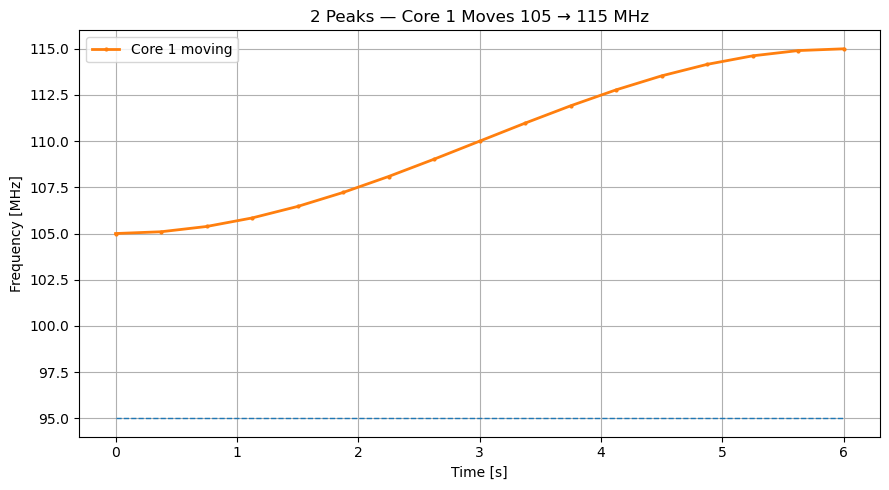

2 Peaks — Core 1 Moves 105 → 115 MHz
Moving cores: {1: 115}
Watch the RIGOL FFT.
RF OUTPUT OFF / CARD RELEASED


In [22]:
run_selected_ramp_test(
    initial_freqs_MHz=[
        95,
        105,
    ],
    moving_targets_MHz={
        1: 115,
    },
    title="2 Peaks — Core 1 Moves 105 → 115 MHz",
)


#### 10.5.2 — Ten Peaks, One Moving

Expected RIGOL FFT behavior:

- nine peaks remain fixed;
- the rightmost peak moves from **108 MHz → 115 MHz**.

The initial ten peaks are spaced by 2 MHz from 90 to 108 MHz.


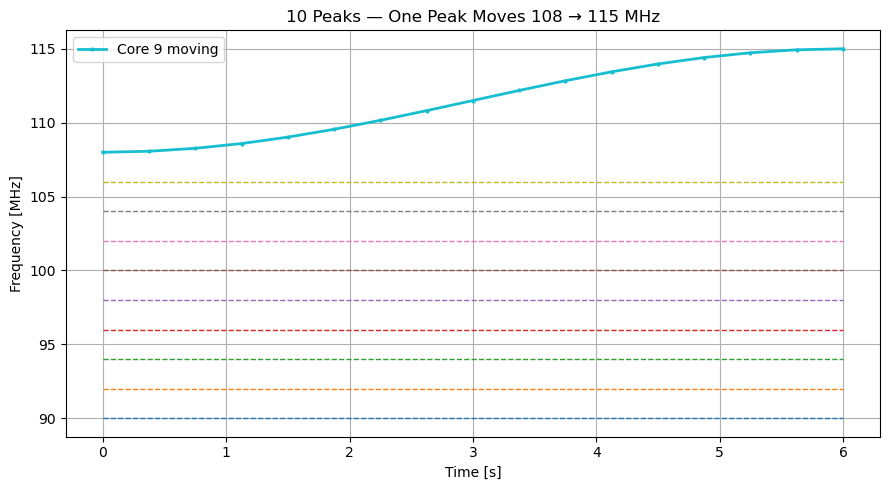

10 Peaks — One Peak Moves 108 → 115 MHz
Moving cores: {9: 115}
Watch the RIGOL FFT.
RF OUTPUT OFF / CARD RELEASED


In [23]:
run_selected_ramp_test(
    initial_freqs_MHz=[
        90, 92, 94, 96, 98,
        100, 102, 104, 106, 108,
    ],
    moving_targets_MHz={
        9: 115,
    },
    title="10 Peaks — One Peak Moves 108 → 115 MHz",
)


#### 10.5.3 — Ten Peaks, Two Moving

Expected RIGOL FFT behavior:

- eight middle peaks remain fixed;
- the leftmost peak moves **90 MHz → 86 MHz**;
- the rightmost peak moves **108 MHz → 115 MHz**.

This makes two simultaneous motions easy to distinguish visually.


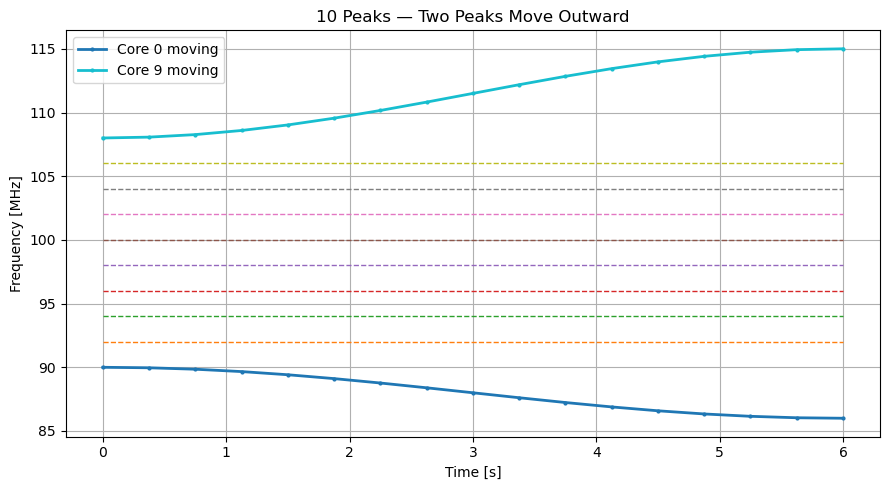

10 Peaks — Two Peaks Move Outward
Moving cores: {0: 86, 9: 115}
Watch the RIGOL FFT.
RF OUTPUT OFF / CARD RELEASED


In [24]:
run_selected_ramp_test(
    initial_freqs_MHz=[
        90, 92, 94, 96, 98,
        100, 102, 104, 106, 108,
    ],
    moving_targets_MHz={
        0: 86,
        9: 115,
    },
    title="10 Peaks — Two Peaks Move Outward",
)


#### 10.6.1 Preview the Full Programmed Complex Ramp

This plots the trajectories **before** sending them to the Spectrum card.

Each line is one DDS carrier. The plotted points are the segment boundaries used to generate the piecewise-linear slope commands.


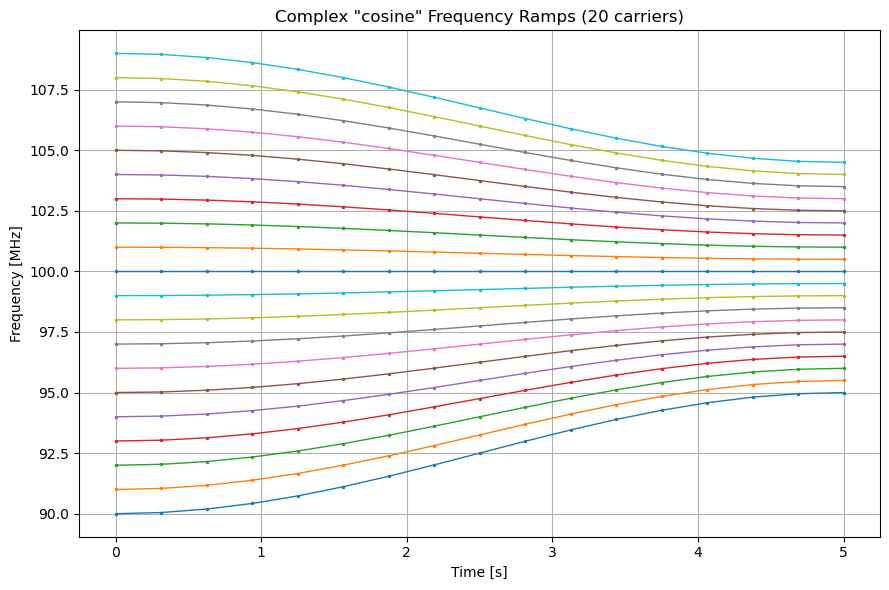

In [25]:
card, dds = open_dds()
available_cores = len(dds)
stop_output(card)

if COMPLEX_NUM_CARRIERS > available_cores:
    raise ValueError(
        f"Requested {COMPLEX_NUM_CARRIERS} carriers, "
        f"but only {available_cores} DDS cores are available."
    )

initial_delta_MHz = (
    COMPLEX_INITIAL_SPAN_MHZ
    / COMPLEX_NUM_CARRIERS
)

final_delta_MHz = (
    COMPLEX_FINAL_SPAN_MHZ
    / COMPLEX_NUM_CARRIERS
)

segment_u = np.linspace(
    0,
    1,
    COMPLEX_RAMP_NUM_SEGMENTS + 1,
)

segment_t_s = (
    segment_u
    * COMPLEX_RAMP_TOTAL_TIME_S
)

plt.figure(figsize=(9, 6))

for core_index in range(COMPLEX_NUM_CARRIERS):
    parameters = {
        "startFreq_Hz": (
            COMPLEX_INITIAL_FIRST_MHZ
            + core_index * initial_delta_MHz
        ) * 1e6,

        "endFreq_Hz": (
            COMPLEX_FINAL_FIRST_MHZ
            + core_index * final_delta_MHz
        ) * 1e6,

        "time_s": COMPLEX_RAMP_TOTAL_TIME_S,
        "ramp_type": COMPLEX_RAMP_TYPE,
    }

    y_Hz = generate_complex_ramp(
        segment_u,
        parameters,
        COMPLEX_RAMP_NUM_SEGMENTS,
    )

    plt.plot(
        segment_t_s,
        y_Hz / 1e6,
        ".-",
        linewidth=1,
        markersize=3,
    )

plt.xlabel("Time [s]")
plt.ylabel("Frequency [MHz]")
plt.title(
    f'Complex "{COMPLEX_RAMP_TYPE}" Frequency Ramps '
    f'({COMPLEX_NUM_CARRIERS} carriers)'
)
plt.grid(True)
plt.tight_layout()
plt.show()


#### 10.6.2 Run the Full Complex S-Shaped Ramp

This follows the finite hardware sequence of Spectrum's `12_dds_complex_ramps.py`:

1. initialize all carrier frequencies;
2. calculate all segment slopes;
3. queue one `frequency_slope()` command per segment;
4. queue the exact final frequencies with zero slope;
5. start the DDS;
6. wait for the finite sequence to complete;
7. automatically stop RF.

There is **no infinite `while True` loop** and no Ctrl+C requirement.


In [33]:
card, dds = open_dds()

if COMPLEX_NUM_CARRIERS > len(dds):
    stop_output(card)
    raise ValueError(
        f"Requested {COMPLEX_NUM_CARRIERS} carriers, "
        f"but only {len(dds)} DDS cores are available."
    )

# Official complex-ramp example uses DMA transfer mode.
dds.data_transfer_mode(
    spcm.SPCM_DDS_DTM_DMA
)

initial_delta = (
    COMPLEX_INITIAL_SPAN_MHZ
    / COMPLEX_NUM_CARRIERS
    * units.MHz
)

final_delta = (
    COMPLEX_FINAL_SPAN_MHZ
    / COMPLEX_NUM_CARRIERS
    * units.MHz
)

first_initial = (
    COMPLEX_INITIAL_FIRST_MHZ
    * units.MHz
)

first_final = (
    COMPLEX_FINAL_FIRST_MHZ
    * units.MHz
)

period_s = (
    COMPLEX_RAMP_TOTAL_TIME_S
    / COMPLEX_RAMP_NUM_SEGMENTS
)

# ------------------------------------------------------------
# STEP 0 — Initialize carriers
# ------------------------------------------------------------

dds.freq_ramp_stepsize(
    COMPLEX_RAMP_STEP_DIVIDER
)

# dds.trg_timer(15.0 * units.s) # Added for debugging

dds.trg_timer(
    period_s * units.s
)

dds.trg_src(
    spcm.SPCM_DDS_TRG_SRC_TIMER
)

# # Disable unused DDS cores.
# for core in dds:
#     core.amp(0 * units.percent)

for core_index in range(COMPLEX_NUM_CARRIERS):
    core = dds[core_index]

    core.amp(
        COMPLEX_TOTAL_AMPLITUDE
        / COMPLEX_NUM_CARRIERS
    )

    core.freq(
        first_initial
        + core_index * initial_delta
    )

dds.exec_at_trg()

# ------------------------------------------------------------
# STEP 1 — Calculate and queue the segment slopes
# ------------------------------------------------------------



segment_u = np.linspace(
    0,
    1,
    COMPLEX_RAMP_NUM_SEGMENTS + 1,
)

segment_t_s = (
    segment_u
    * COMPLEX_RAMP_TOTAL_TIME_S
)

slopes = np.zeros(
    (
        COMPLEX_NUM_CARRIERS,
        COMPLEX_RAMP_NUM_SEGMENTS,
    )
)

for core_index in range(COMPLEX_NUM_CARRIERS):
    parameters = {
        "startFreq_Hz": (
            COMPLEX_INITIAL_FIRST_MHZ
            + core_index
            * COMPLEX_INITIAL_SPAN_MHZ
            / COMPLEX_NUM_CARRIERS
        ) * 1e6,

        "endFreq_Hz": (
            COMPLEX_FINAL_FIRST_MHZ
            + core_index
            * COMPLEX_FINAL_SPAN_MHZ
            / COMPLEX_NUM_CARRIERS
        ) * 1e6,

        "time_s": COMPLEX_RAMP_TOTAL_TIME_S,
        "ramp_type": COMPLEX_RAMP_TYPE,
    }

    y_Hz = generate_complex_ramp(
        segment_u,
        parameters,
        COMPLEX_RAMP_NUM_SEGMENTS,
    )

    slopes[core_index, :] = (
        calculate_complex_slopes(
            segment_t_s,
            y_Hz,
        )
    )

for segment in range(
    COMPLEX_RAMP_NUM_SEGMENTS
):
    for core_index in range(
        COMPLEX_NUM_CARRIERS
    ):
        dds[core_index].frequency_slope(
            slopes[core_index, segment]
        )

    dds.exec_at_trg()

# ------------------------------------------------------------
# STEP 2 — Stop the ramp at exact final frequencies
# ------------------------------------------------------------

for core_index in range(
    COMPLEX_NUM_CARRIERS
):
    core = dds[core_index]

    core.frequency_slope(0)

    core.freq(
        first_final
        + core_index * final_delta
    )

dds.exec_at_trg()
dds.write_to_card()

# ------------------------------------------------------------
# Run the finite sequence
# ------------------------------------------------------------

try:
    start_output(card)

    print("COMPLEX S-SHAPED RAMP ON")
    print("Ramp type:", COMPLEX_RAMP_TYPE)
    print("Watch the multiple tones on the RIGOL FFT.")

    # Initial command + one trigger per segment + final command.
    sequence_time_s = (
        (COMPLEX_RAMP_NUM_SEGMENTS + 2)
        * period_s
    )

    time.sleep(
        sequence_time_s
        + COMPLEX_FINAL_HOLD_S
    )

finally:
    stop_output(card)
    print("RF OUTPUT OFF")


COMPLEX S-SHAPED RAMP ON
Ramp type: cosine
Watch the multiple tones on the RIGOL FFT.
RF OUTPUT OFF


### 10.7 What to Verify on the RIGOL

- **Single tone:** one clean FFT peak at the programmed frequency.
- **Multi-tone:** one peak per programmed DDS core.
- **Test A:** discrete frequency jumps are visible.
- **Test B:** timer-triggered steps happen automatically.
- **Test C:** one peak moves continuously during the simple linear ramp.
- **10.5.1:** 2 peaks total; only the 105 MHz peak moves toward 115 MHz.
- **10.5.2:** 10 peaks total; only the 108 MHz peak moves toward 115 MHz.
- **10.5.3:** 10 peaks total; the 90 MHz and 108 MHz peaks move outward while the other 8 remain fixed.
- **Test E / Full Complex Ramp:** all programmed carriers follow their coordinated S-shaped trajectories.

For the visualization tests, the fixed peaks should remain at fixed x-positions in the RIGOL FFT while the selected moving peaks visibly shift left or right.


## 11. AOD Specifications / Future AOD Test Settings

AOD: **AA Opto-Electronic DTSX-400-800**

Known values:
- optical wavelength range: approximately 780–820 nm;
- active aperture: approximately 7.5 × 7.5 mm²;
- RF input impedance: 50 Ω;
- RF span: approximately 36 MHz;
- maximum RF power at AOD input: < 2 W.

Future chain:

`M4i CH0 → RF amplifier → cable / loss → AOD`

The RF power limit applies at the **AOD RF input**.


In [ ]:
AOD_MODEL = "DTSX-400-800"
AOD_RF_SPAN = 36 * units.MHz
AOD_IMPEDANCE = 50 * units.ohm
AOD_MAX_RF_POWER = 2 * units.W

AOD_CENTER_FREQUENCY = 103 * units.MHz

# Keep unit-specific calibrated endpoints separate.
AOD_RF_MIN = None
AOD_RF_MAX = None

print("AOD model:", AOD_MODEL)
print("Center frequency:", AOD_CENTER_FREQUENCY)
print("RF span:", AOD_RF_SPAN)
print("Maximum RF power at AOD input:", AOD_MAX_RF_POWER)


## 12. AOD Frequency Readiness Check

The working center frequency is currently set to **103 MHz**.

The exact calibrated lower / upper endpoints should still be entered from the actual AOD calibration information before an optical scan is treated as calibrated.


In [ ]:
print("AOD center frequency:", AOD_CENTER_FREQUENCY)

if AOD_RF_MIN is None or AOD_RF_MAX is None:
    print(
        "Calibrated AOD RF endpoints are not entered yet. "
        "Do not treat 103 ± 18 MHz as unit-specific calibrated limits."
    )
else:
    print(
        "AOD calibrated RF interval:",
        AOD_RF_MIN,
        "to",
        AOD_RF_MAX,
    )


## 13. Emergency / Manual Stop

If a hardware-control cell is interrupted and you are unsure whether the card is still outputting, run this cell.

If software state is uncertain, physically disconnect the RF cable as required by the lab procedure.


In [ ]:
with spcm.Card(DEVICE) as card:
    card.stop()

print("Stop command sent to M4i.6622-x8")


## 14. Quick Troubleshooting

### `import spcm` fails
Run the `%pip install spcm` cell at the top.

### RIGOL shows no signal
Check:
- Spectrum CH0 physical connection;
- RIGOL input / termination;
- vertical scale and time base;
- RF output cell actually reached `RF output ON`.

### 100 MHz tone exists in time domain but FFT peak is missing
Check:
- RIGOL sample rate is comfortably above 200 MSa/s, preferably much higher;
- shorten the time base if the sample rate has dropped;
- FFT center / span includes 100 MHz;
- FFT source is the correct input channel;
- use Vrms if it gives a cleaner display.

### Complex ramp
If the 20-carrier FFT is too crowded, reduce:
```python
COMPLEX_NUM_CARRIERS
```
while keeping the same complex-ramp algorithm.

### Before connecting the AOD
Confirm:
- actual AOD operating frequency range;
- RF amplifier gain;
- cable / coupler loss;
- final RF power at the AOD remains below the allowed limit.
